In [1932]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1933]:
#data loading
df= pd.read_csv('Churn Rate Dataset.csv')

In [1934]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1935]:
#removing Cutomer ID column
df.drop('customerID',axis=1, inplace= True)

In [1936]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1937]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [1938]:
#changing TotalCharges to numeric
df['TotalCharges']= df['TotalCharges'].replace(' ',0).astype(float)

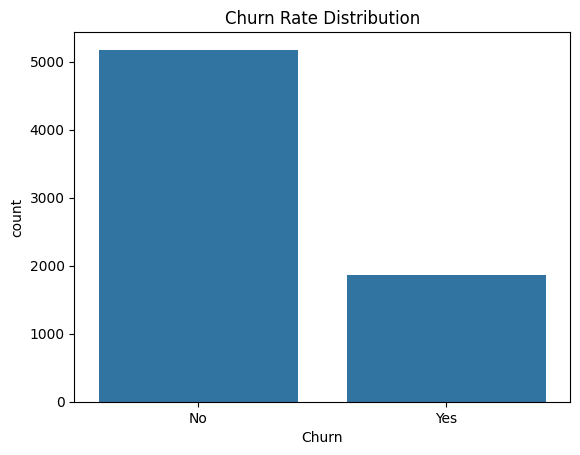

In [1939]:
#churn rate distribution
sns.countplot(x='Churn',data=df)
plt.title('Churn Rate Distribution')
plt.savefig('Churn Rate Distribution.png', dpi=300,bbox_inches='tight')
plt.show()

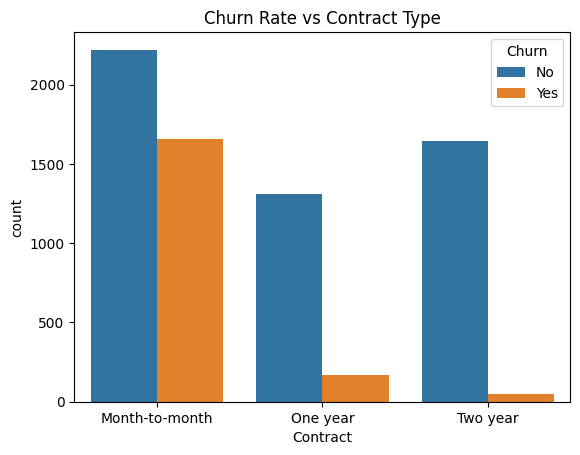

In [1940]:
#churn rate vs contract type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn Rate vs Contract Type')
plt.savefig('Churn Rate vs Contract Type.png', dpi=300,bbox_inches='tight')
plt.show()

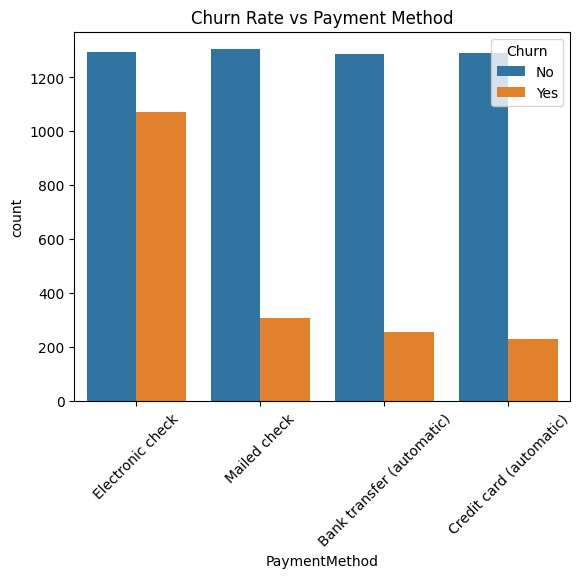

In [1941]:
# churn vs payment method
sns.countplot(x='PaymentMethod',hue='Churn', data=df)
plt.title('Churn Rate vs Payment Method')
plt.savefig('Churn Rate vs Payment Method.png', dpi=300,bbox_inches='tight')
plt.xticks(rotation=45)
plt.show()

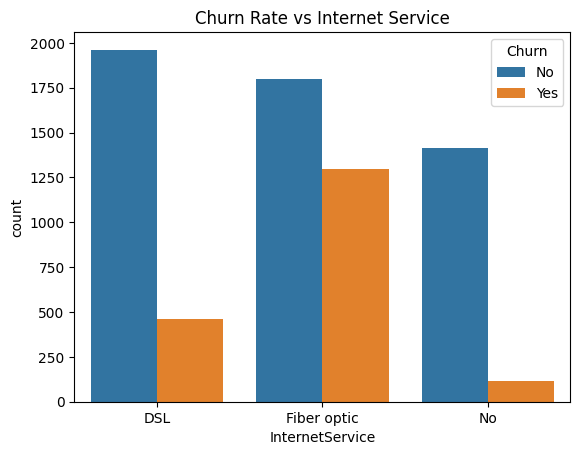

In [1942]:
#churn rate vs internet service
sns.countplot(x='InternetService',hue='Churn' , data=df)
plt.title('Churn Rate vs Internet Service')
plt.savefig('Churn Rate vs Internet Service.png', dpi=300,bbox_inches='tight')
plt.show()

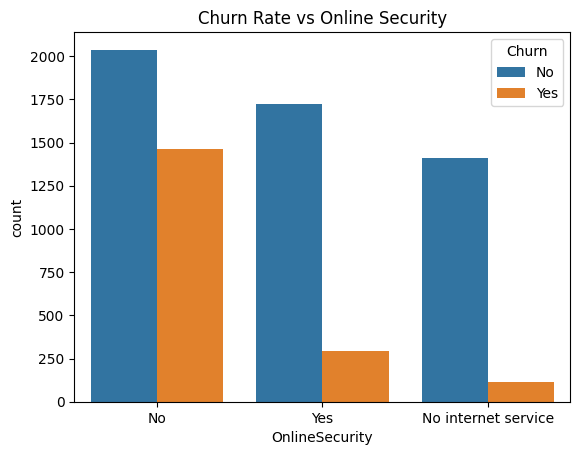

In [1943]:
#churn rate vs online security
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title('Churn Rate vs Online Security')
plt.savefig('Churn Rate vs Online Security.png', dpi=300,bbox_inches='tight')
plt.show()

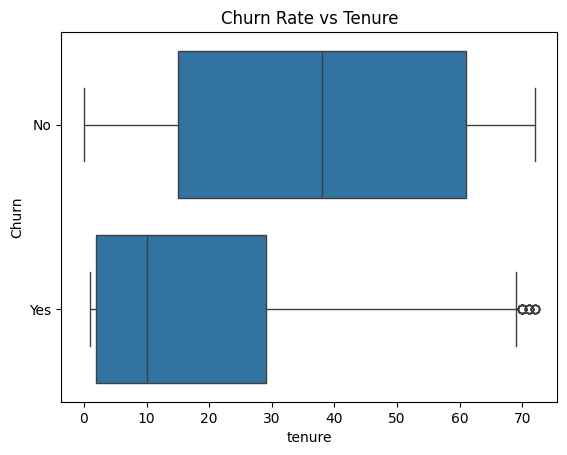

In [1944]:
#churn rate vs tenure
sns.boxplot(x='tenure',y='Churn', data=df)
plt.title('Churn Rate vs Tenure')
plt.savefig('Churn Rate vs Tenure.png', dpi=300,bbox_inches='tight')
plt.show()

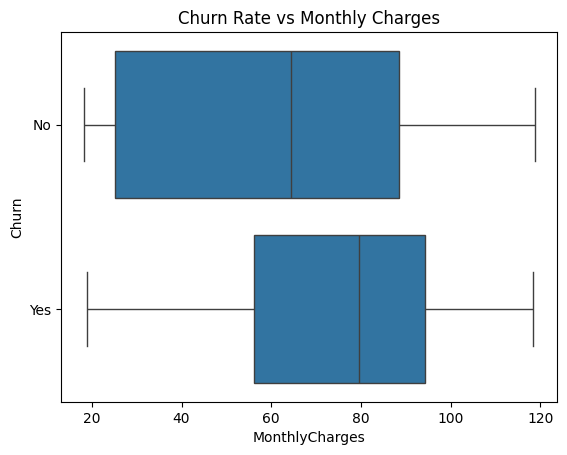

In [1945]:
#churn vs monthly charges
sns.boxplot(x='MonthlyCharges',y='Churn', data=df)
plt.title('Churn Rate vs Monthly Charges')
plt.savefig('Churn Rate vs Monthly Charges.png', dpi=300,bbox_inches='tight')
plt.show()

EDA Summary:

Churn dataset is imbalanced.

Customers with month-to-month contracts are more likely to churn.

Low tenure customers have higher churn probability.

Higher monthly charges correlate with churn.

Certain payment methods show higher churn behavior.

In [1946]:
#mapping churn to binary values
df['Churn']= df['Churn'].map({'Yes':1, 'No':0})

In [1947]:
X= df.drop('Churn',axis=1)
y=df['Churn']

In [1948]:
#train test split
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test= train_test_split(X,y, random_state= 64, shuffle=True, test_size=0.10, stratify=y)

In [1949]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [1950]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = ["Contract"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression( max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [1951]:
y_prob = pipeline.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.4).astype(int)

In [1952]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7886524822695036
Confusion Matrix:
 [[423  95]
 [ 54 133]]
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       518
           1       0.58      0.71      0.64       187

    accuracy                           0.79       705
   macro avg       0.74      0.76      0.75       705
weighted avg       0.81      0.79      0.79       705

ROC-AUC: 0.8664804988334399


In [1953]:
import pickle

pickle.dump(pipeline, open('churn_model.pkl', 'wb'))